In [1]:
from notebooks.consts import NOTEBOOK_PATH

SEEN_MODELS_FOLDER = NOTEBOOK_PATH / 'models' / 'SeenOligoModel'

In [2]:
import xgboost as xgb
import json

# 1. Reload your trained models
model_train_val = xgb.Booster()
model_train_val.load_model(str( SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"))

model_all = xgb.Booster()
model_all.load_model(str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_AllData.json"))

# 2. Recover the optimal features directly from the model!
best_feats = model_train_val.feature_names
print(f"Successfully recovered {len(best_feats)} optimal features!")

# 3. (Optional) Load your metrics back into a dictionary
with open(str(  SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal_metrics.json"), "r") as f:
    train_val_metrics = json.load(f)

# Recreate the dictionary the pipeline was supposed to return
models = {'model_train_val': model_train_val, 'model_all': model_all}

Successfully recovered 50 optimal features!


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming you have your data loaded: train_df, val_df, test_df, INHIBITION

def get_large_cohort_indices(df, group_cols, min_size=20):
    indices = []
    df_reset = df.reset_index(drop=True)
    for cohort, group in df_reset.groupby(group_cols):
        if len(group) >= min_size:
            indices.append(group.index.values)
    return indices

def evaluate_predictions(preds, y_true, eval_groups):
    """Calculates Spearman, MAE, RMSE, and Top K% Medians."""
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))

    spearmans, top_1_medians, top_5_medians = [], [], []
    for idxs in eval_groups:
        t_vals, p_vals = y_true[idxs], preds[idxs]

        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr): spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))

        if k5 > 0: top_5_medians.append(np.median(t_vals[np.argpartition(p_vals, -k5)[-k5:]]))
        if k1 > 0: top_1_medians.append(np.median(t_vals[np.argpartition(p_vals, -k1)[-k1:]]))

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Spearman": float(np.nanmedian(spearmans)) if spearmans else 0.0,
        "Top1_Inhib": float(np.nanmedian(top_1_medians)) if top_1_medians else 0.0,
        "Top5_Inhib": float(np.nanmedian(top_5_medians)) if top_5_medians else 0.0
    }


In [6]:
from tauso.data.consts import CANONICAL_GENE, CELL_LINE, INHIBITION

COMPETITION = [
    "PFRED_PLS",
    "PFRED_SVM",
    "OW_Overall",
    "OW_Tm",
    "OW_Intra_Oligo",
    "OW_Duplex",
    "sfold_accessibility",
    "miranda_score",
    "miranda_energy",
    "oligo_ai_score",
]

# 1. Dynamically create dictionary entries for all competition/baseline features
MODELS_TO_COMPARE = {
    f"Competition ({col})": {
        "is_baseline": True,
        "baseline_col": col,
        "is_all_data": False
    } for col in COMPETITION
}

# 2. Add your trained XGBoost models to the dictionary
MODELS_TO_COMPARE.update({
    "L2 (Train+Val)": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"),
        "is_all_data": False
    },
    "L2 (Train+Val) [CustomId]": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_CustomId_TrainVal.json"),
    "is_all_data": False
    },
    "L1 (Train+Val)": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
    "is_all_data": False
    },
    "L1 (Train+Val) [CustomId]": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_CustomId_TrainVal.json"),
    "is_all_data": False
    },
    # "L1 (Train+Val)": {
    #     "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
    #     "is_all_data": False
    # },
    # "L2 (All Data)": {
    #     "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_AllData.json"),
    #     "is_all_data": True
    # },
})


# Define the multiple groupings you want to track
EVAL_GROUPS = {
    'Experiment (custom_id)': 'custom_id',
    'Cohort (Gene x Cell Line)': [CANONICAL_GENE, CELL_LINE]
}


In [8]:
from notebooks.models.SeenOligoModel.base_model import split_data
from notebooks.models.utility import load_and_validate_final_data

final_data, features = load_and_validate_final_data(version='oligo', load_competition=True)


[Loading features] finished in 36.3670s


In [10]:
# Default config
split_config = {
    'col': 'split',
    'train': 'train',
    'val': 'val',
    'test': 'test'
}

train_df, val_df, test_df = split_data(
    final_data,
    features,
    split_col=split_config["col"],
    train_val=split_config["train"],
    val_val=split_config["val"],
    test_val=split_config["test"],
)

In [12]:
from tauso.data.consts import MODIFICATION

def evaluate_multiple_models_per_modification(model_configs, train_df, val_df, test_df, target_col, eval_groups_dict, mod_col):
    y_train, y_val, y_test = train_df[target_col].values, val_df[target_col].values, test_df[target_col].values
    all_metrics = []

    print(f"Evaluating {len(model_configs)} configurations across {len(eval_groups_dict)} grouping strategies per modification...")
    for model_name, config in model_configs.items():
        try:
            if config.get('is_baseline', False):
                baseline_col = config['baseline_col']
                preds_train = train_df[baseline_col].values
                preds_val = val_df[baseline_col].values
                preds_test = test_df[baseline_col].values
            else:
                bst = xgb.Booster()
                bst.load_model(config['path'])
                model_features = bst.feature_names

                dtrain = xgb.DMatrix(train_df[model_features].values, feature_names=model_features)
                dval = xgb.DMatrix(val_df[model_features].values, feature_names=model_features)
                dtest = xgb.DMatrix(test_df[model_features].values, feature_names=model_features)

                preds_train = bst.predict(dtrain)
                preds_val = bst.predict(dval)
                preds_test = bst.predict(dtest)

            test_split_name = "Test (Leaked)" if config.get('is_all_data', False) else "Test"

            # Get unique modifications across all splits
            all_mods = pd.concat([train_df[mod_col], val_df[mod_col], test_df[mod_col]]).dropna().unique()

            for mod in all_mods:
                train_mask = (train_df[mod_col] == mod).values
                val_mask = (val_df[mod_col] == mod).values
                test_mask = (test_df[mod_col] == mod).values

                for group_label, group_cols in eval_groups_dict.items():
                    if train_mask.sum() > 0:
                        train_sub = train_df[train_mask].reset_index(drop=True)
                        train_eval_idx = get_large_cohort_indices(train_sub, group_cols, min_size=1)
                        metrics_train = evaluate_predictions(preds_train[train_mask], y_train[train_mask], train_eval_idx)
                        metrics_train.update({"Model": model_name, "Split": "Train", "Grouping": group_label, "Modification": mod})
                        all_metrics.append(metrics_train)

                    if val_mask.sum() > 0:
                        val_sub = val_df[val_mask].reset_index(drop=True)
                        val_eval_idx = get_large_cohort_indices(val_sub, group_cols, min_size=1)
                        metrics_val = evaluate_predictions(preds_val[val_mask], y_val[val_mask], val_eval_idx)
                        metrics_val.update({"Model": model_name, "Split": "Validation", "Grouping": group_label, "Modification": mod})
                        all_metrics.append(metrics_val)

                    if test_mask.sum() > 0:
                        test_sub = test_df[test_mask].reset_index(drop=True)
                        test_eval_idx = get_large_cohort_indices(test_sub, group_cols, min_size=1)
                        metrics_test = evaluate_predictions(preds_test[test_mask], y_test[test_mask], test_eval_idx)
                        metrics_test.update({"Model": model_name, "Split": test_split_name, "Grouping": group_label, "Modification": mod})
                        all_metrics.append(metrics_test)

        except Exception as e:
            print(f"❌ Failed to evaluate '{model_name}': {e}")

    df_results = pd.DataFrame(all_metrics)
    cols = ['Model', 'Split', 'Modification', 'Grouping', 'Spearman', 'Top1_Inhib', 'Top5_Inhib', 'MAE', 'RMSE']
    return df_results[cols]

# Run the evaluation
df_comparison_mod = evaluate_multiple_models_per_modification(
    model_configs=MODELS_TO_COMPARE,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=INHIBITION,
    eval_groups_dict=EVAL_GROUPS,
    mod_col=MODIFICATION
)

Evaluating 14 configurations across 2 grouping strategies per modification...


/tmp/ipykernel_73762/2470624892.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_73762/2470624892.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_73762/2470624892.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_73762/2470624892.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_73762/2470624892.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_73762/2470624892.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = 

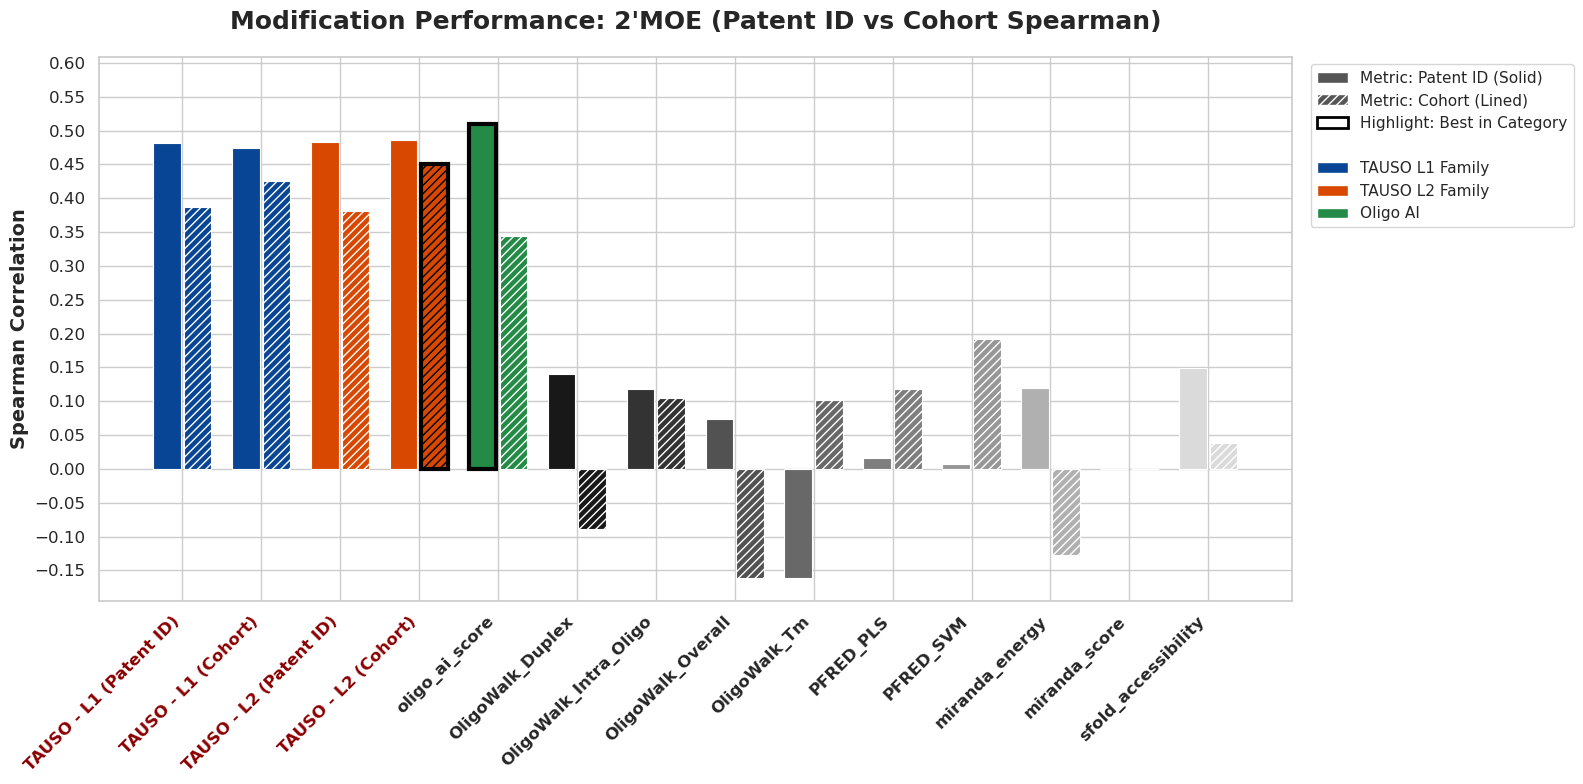

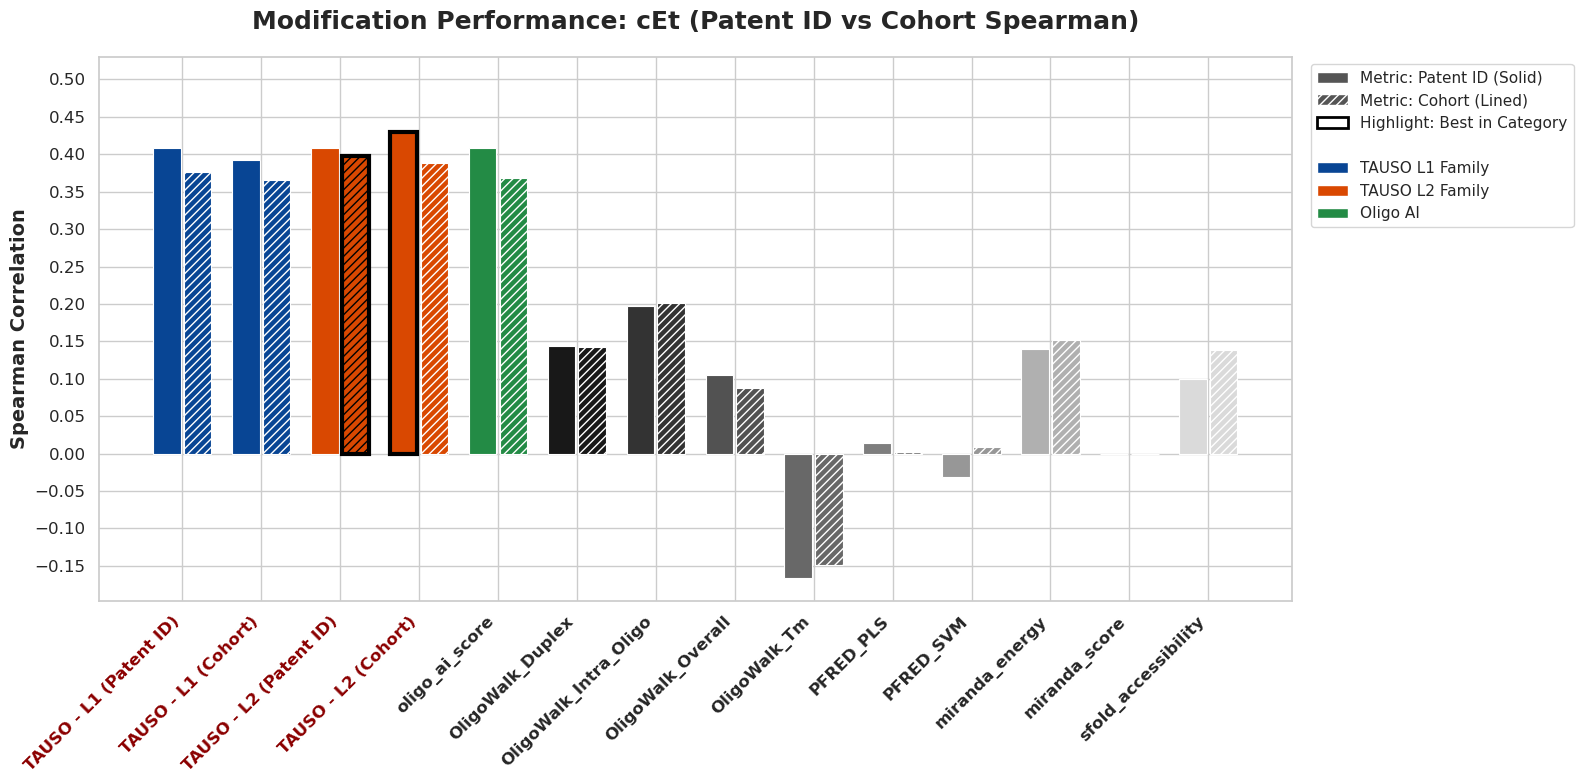

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

def plot_modifications_separated_for_paper(df):
    # --- 1. Environmental Setup ---
    plt.style.use('default')
    sns.set_theme(style="whitegrid")

    # --- 2. Data Preparation ---
    df_plot = df[df['Split'] == 'Test'].copy()

    # Rename Groupings
    group_map = {'Experiment (custom_id)': 'Patent ID', 'Cohort (Gene x Cell Line)': 'Cohort'}
    df_plot['Grouping'] = df_plot['Grouping'].replace(group_map)

    # Shorten Modifications
    mod_map = {'MOE/5-methylcytosines/deoxy': "2'MOE", 'cEt/5-methylcytosines/deoxy': "cEt"}
    df_plot['Modification'] = df_plot['Modification'].replace(mod_map)

    # Clean Model Names
    df_plot['Model'] = df_plot['Model'].str.replace(r'^Competition \((.*)\)$', r'\1', regex=True)
    df_plot['Model'] = df_plot['Model'].str.replace('OW_', 'OligoWalk_', regex=False)

    tauso_rename = {
        "L1 (Train+Val)": "TAUSO - L1 (Cohort)",
        "L1 (Train+Val) [CustomId]": "TAUSO - L1 (Patent ID)",
        "L2 (Train+Val)": "TAUSO - L2 (Cohort)",
        "L2 (Train+Val) [CustomId]": "TAUSO - L2 (Patent ID)"
    }
    df_plot['Model'] = df_plot['Model'].replace(tauso_rename)
    df_plot['Spearman'] = df_plot['Spearman'].fillna(0)

    # --- 3. Color & Model Mapping ---
    color_dict = {
        "TAUSO - L1 (Patent ID)": "#084594", "TAUSO - L1 (Cohort)": "#084594",
        "TAUSO - L2 (Patent ID)": "#d94801", "TAUSO - L2 (Cohort)": "#d94801",
        "oligo_ai_score": "#238b45"
    }

    others = sorted([m for m in df_plot['Model'].unique() if m not in color_dict])
    grey_palette = sns.color_palette("Greys_r", n_colors=len(others) + 2)
    for i, m in enumerate(others):
        color_dict[m] = grey_palette[i]

    model_order = [
        "TAUSO - L1 (Patent ID)", "TAUSO - L1 (Cohort)",
        "TAUSO - L2 (Patent ID)", "TAUSO - L2 (Cohort)",
        "oligo_ai_score"
    ] + others

    mods = sorted(df_plot['Modification'].unique())

    # --- 4. Legend Construction ---
    legend_elements = [
        mpatches.Patch(facecolor='#555555', edgecolor='white', label='Metric: Patent ID (Solid)'),
        mpatches.Patch(facecolor='#555555', edgecolor='white', hatch='////', label='Metric: Cohort (Lined)'),
        mpatches.Patch(facecolor='none', edgecolor='black', linewidth=2, label='Highlight: Best in Category'),
        mpatches.Patch(facecolor='none', label=''),
        mpatches.Patch(facecolor='#084594', label='TAUSO L1 Family'),
        mpatches.Patch(facecolor='#d94801', label='TAUSO L2 Family'),
        mpatches.Patch(facecolor='#238b45', label='Oligo AI'),
    ]

    # --- 5. Generate a Separate Plot for Each Modification ---
    for mod in mods:
        # Standard paper-width figure
        fig, ax = plt.subplots(figsize=(16, 8))

        # Isolate data for this specific modification
        mod_df = df_plot[df_plot['Modification'] == mod]

        # Identify the absolute best performers for this modification to highlight them
        best_p = mod_df[mod_df['Grouping'] == 'Patent ID']['Spearman'].max()
        best_c = mod_df[mod_df['Grouping'] == 'Cohort']['Spearman'].max()

        # Layout math
        bar_width = 0.35
        inner_gap = 0.04
        unit_width = 1.0
        x_ticks = []

        for i, model in enumerate(model_order):
            x_center = i * unit_width
            x_ticks.append(x_center)

            # Retrieve values
            val_p_data = mod_df[(mod_df['Model'] == model) & (mod_df['Grouping'] == 'Patent ID')]['Spearman'].values
            val_c_data = mod_df[(mod_df['Model'] == model) & (mod_df['Grouping'] == 'Cohort')]['Spearman'].values

            v_p = val_p_data[0] if len(val_p_data) > 0 else 0
            v_c = val_c_data[0] if len(val_c_data) > 0 else 0
            color = color_dict[model]

            is_best_p = np.isclose(v_p, best_p, rtol=1e-5) if not pd.isna(best_p) else False
            is_best_c = np.isclose(v_c, best_c, rtol=1e-5) if not pd.isna(best_c) else False

            # Draw Patent ID Bar (Solid)
            ax.bar(x_center - (bar_width + inner_gap)/2, v_p, width=bar_width, color=color,
                   edgecolor='black' if is_best_p else 'white', linewidth=3 if is_best_p else 0.8)

            # Draw Cohort Bar (Hatched)
            ax.bar(x_center + (bar_width + inner_gap)/2, v_c, width=bar_width, color=color, hatch='////',
                   edgecolor='black' if is_best_c else 'white', linewidth=3 if is_best_c else 0.8)

        # --- 6. Formatting & Aesthetics ---
        # Apply X-axis labels directly
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(model_order, rotation=45, ha='right', fontsize=12, fontweight='bold')

        # Color the TAUSO labels on the X-axis red so they stand out
        for label in ax.get_xticklabels():
            if 'TAUSO' in label.get_text():
                label.set_color('#8B0000')

        # Y-Axis formatting
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylim(top=mod_df['Spearman'].max() + 0.1) # Dynamic top limit

        ax.set_title(f"Modification Performance: {mod} (Patent ID vs Cohort Spearman)", fontsize=18, fontweight='bold', pad=20)
        ax.set_ylabel('Spearman Correlation', fontsize=14, fontweight='bold')

        # Attach legend outside
        ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, frameon=True)

        plt.tight_layout()
        plt.show()

# Run the separated plots
plot_modifications_separated_for_paper(df_comparison_mod)